# Mineração de dados - Modelagem

## Importar bibliotecas

In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

## Carregar dados pré-processados

In [33]:
df = pd.read_csv('../data/processed/pns_2019_transformed.csv')
df.shape

(87657, 70)

In [34]:
df.head()

,situacao_domicilio,acesso_internet,plano_saude,hipertensao,diabetes,doenca_coracao,infarto,angina,insuficiencia_cardiaca,arritmia,...,tabagismo_ativo,alcool_status,alcool_ativo,atividade_status,atividade_ativo,faixa_etaria,renda_domiciliar_log,renda_per_capita_log,idade_c,idade_c2
0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,1,True,1,True,50-59,7.649216,5.860786,7.636275,58.312703
1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,1,True,0,False,18-29,6.908755,5.525453,-28.363725,804.500868
2,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,3,True,0,False,40-49,8.294300,6.216606,-2.363725,5.587194
3,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,0,False,2,True,50-59,5.783825,5.783825,10.636275,113.130356
4,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,0,False,1,True,18-29,0.000000,0.000000,-19.363725,374.953827


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87657 entries, 0 to 87656
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   situacao_domicilio      87657 non-null  int64  
 1   acesso_internet         87657 non-null  int64  
 2   plano_saude             87657 non-null  float64
 3   hipertensao             85995 non-null  float64
 4   diabetes                81504 non-null  float64
 5   doenca_coracao          87657 non-null  float64
 6   infarto                 87657 non-null  float64
 7   angina                  87657 non-null  float64
 8   insuficiencia_cardiaca  87657 non-null  float64
 9   arritmia                87657 non-null  float64
 10  avc                     87657 non-null  float64
 11  asma                    87657 non-null  float64
 12  artrite                 87657 non-null  float64
 13  dort                    87657 non-null  float64
 14  depressao               87657 non-null  float64
 

## Descartar NaN

In [36]:
df = df.dropna()
df.shape

(74304, 70)

## Remover variaveis que não serão utilizadas 

In [37]:
colunas_remover = [
    "doenca_cronica",
    "n_doencas",
    "hipertensao",
    "diabetes",
    "doenca_coracao",
    "infarto",
    "angina",
    "insuficiencia_cardiaca",
    "arritmia",
    "avc",
    "asma",
    "artrite",
    "dort",
    "depressao",
    "doenca_pulmao",
    "enfisema",
    "bronquite",
    "insuficiencia_renal"
]

## Separar grupos de features

### Variaveis DSS

In [38]:
dss_socioeconomico = [
    "escolaridade_ord",
    "renda_domiciliar_log",
    "renda_per_capita_log"
]

dss_infraestrutura = [
    "situacao_domicilio",
    "infra_agua",
    "acesso_internet",
    "domicilio_Apartamento",
    "domicilio_Cortico",
    "domicilio_Ignorado"
]

dss_demografia = [
    "raca_Preta",
    "raca_Amarela",
    "raca_Parda",
    "raca_Indigena"
]

dss_geografico = [
    col for col in df.columns if col.startswith("uf_")
]

### Variaveis biomedicas / comportamentais

In [39]:
comportamentais = [
    "tabagismo_status",
    "tabagismo_ativo",
    "alcool_status",
    "alcool_ativo",
    "atividade_status",
    "atividade_ativo"
]

biomedicas = [
    "imc",
    "idade_c",
    "idade_c2",
    "sexo_feminino"
]

### Modelo 1 - DSS + Biomedicas + Comportamentais

In [40]:
features_modelo1 = (
    dss_socioeconomico
    + dss_infraestrutura
    + dss_demografia
    + dss_geografico
    + comportamentais
    + biomedicas
)

### Modelo 2 - Sem DSS

In [41]:
features_modelo2 = (
    comportamentais
    + biomedicas
)

## Definir variavel alvo

In [42]:
y = df["doenca_cronica"]

## Criar matriz X

In [43]:
# Modelo 1: DSS
X1 = df[features_modelo1]

# Modelo 2: Sem DSS
X2 = df[features_modelo2]

## Dividir Treino e Teste

In [44]:
# Modelo 1
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Modelo 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Padronização
Lasso necessita de escala padronizada

In [45]:
scaler = StandardScaler()

# Modelo 1
X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)

# Modelo 2
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

## Treinar Modelo LASSO L1
usar cross validation para escolher λ automaticamente



In [46]:
modelo1 = LogisticRegressionCV(

    penalty="l1",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

modelo1.fit(X1_train_scaled, y1_train)



d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass settin

In [47]:
modelo2 = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

modelo2.fit(X2_train_scaled, y2_train)

d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass settin

## Avaliação 

### Predição

In [48]:
y_pred = modelo1.predict(X1_test_scaled)
y_prob = modelo1.predict_proba(X1_test_scaled)[:,1]

In [49]:
y_pred2 = modelo2.predict(X2_test_scaled)
y_prob2 = modelo2.predict_proba(X2_test_scaled)[:,1]

### Métricas

In [50]:
print("AUC:", roc_auc_score(y1_test, y_prob))
print("Accuracy:", accuracy_score(y1_test, y_pred))
print(classification_report(y1_test, y_pred))

AUC: 0.7664695576992668
Accuracy: 0.7062108875580378
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      7930
           1       0.70      0.66      0.68      6931

    accuracy                           0.71     14861
   macro avg       0.71      0.70      0.70     14861
weighted avg       0.71      0.71      0.71     14861



In [51]:
print("AUC:", roc_auc_score(y2_test, y_prob2))
print("Accuracy:", accuracy_score(y2_test, y_pred2))
print(classification_report(y2_test, y_pred2))

AUC: 0.7641147753854742
Accuracy: 0.7039230199851961
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      7930
           1       0.69      0.65      0.67      6931

    accuracy                           0.70     14861
   macro avg       0.70      0.70      0.70     14861
weighted avg       0.70      0.70      0.70     14861



## Matriz de Confusão

In [52]:
confusion_matrix(y1_test, y_pred)



array([[5953, 1977],
       [2389, 4542]])

In [53]:
confusion_matrix(y2_test, y_pred2)

array([[5926, 2004],
       [2396, 4535]])

## Extrair coeficientes

In [54]:
coef1 = pd.Series(
    modelo1.coef_[0],
    index=features_modelo1
)

coef2 = pd.Series(
    modelo2.coef_[0],
    index=features_modelo2
)

## Variaveis selecionadas pelo LASSO

In [55]:
coef_selecionados1 = coef1[coef1 != 0]

coef_selecionados1.sort_values()


tabagismo_ativo         -0.137776
alcool_ativo            -0.127351
uf_PA                   -0.042506
uf_AM                   -0.033357
uf_MA                   -0.033089
idade_c2                -0.021814
uf_MT                   -0.020729
uf_RR                   -0.020158
uf_AP                   -0.019217
uf_DF                   -0.016480
uf_RO                   -0.014084
escolaridade_ord        -0.013904
uf_TO                   -0.012891
raca_Indigena           -0.008910
atividade_ativo         -0.005195
uf_PE                   -0.005093
uf_CE                   -0.003793
atividade_status        -0.001855
domicilio_Apartamento   -0.000171
acesso_internet          0.003567
uf_PB                    0.006521
uf_AL                    0.006903
uf_RJ                    0.007227
situacao_domicilio       0.011624
alcool_status            0.012707
renda_per_capita_log     0.013162
uf_RN                    0.017714
uf_MS                    0.019439
uf_SE                    0.020977
raca_Parda    

In [56]:
coef_selecionados2 = coef2[coef2 != 0]

coef_selecionados2.sort_values()

tabagismo_ativo    -0.136127
alcool_ativo       -0.133550
idade_c2           -0.023157
atividade_status   -0.001219
alcool_status       0.041802
tabagismo_status    0.227411
sexo_feminino       0.297744
imc                 0.355204
idade_c             0.929350
dtype: float64

## Calcular ODDS Ratio
Odds Ratio = exp(coeficiente)

In [57]:
odds_ratio1 = np.exp(coef_selecionados1)

odds_ratio1.sort_values()

tabagismo_ativo          0.871294
alcool_ativo             0.880425
uf_PA                    0.958385
uf_AM                    0.967193
uf_MA                    0.967452
idade_c2                 0.978423
uf_MT                    0.979485
uf_RR                    0.980044
uf_AP                    0.980967
uf_DF                    0.983655
uf_RO                    0.986015
escolaridade_ord         0.986193
uf_TO                    0.987192
raca_Indigena            0.991130
atividade_ativo          0.994819
uf_PE                    0.994920
uf_CE                    0.996214
atividade_status         0.998147
domicilio_Apartamento    0.999829
acesso_internet          1.003574
uf_PB                    1.006543
uf_AL                    1.006926
uf_RJ                    1.007254
situacao_domicilio       1.011692
alcool_status            1.012788
renda_per_capita_log     1.013249
uf_RN                    1.017872
uf_MS                    1.019629
uf_SE                    1.021199
raca_Parda    

In [58]:
odds_ratio2 = np.exp(coef_selecionados2)

odds_ratio2.sort_values()

tabagismo_ativo     0.872732
alcool_ativo        0.874984
idade_c2            0.977109
atividade_status    0.998782
alcool_status       1.042688
tabagismo_status    1.255345
sexo_feminino       1.346816
imc                 1.426472
idade_c             2.532863
dtype: float64

## Tabelas Finais

In [59]:
resultado1 = pd.DataFrame({

    "coeficiente": coef_selecionados1,
    "odds_ratio": np.exp(coef_selecionados1)

}).sort_values("odds_ratio")

resultado1


,coeficiente,odds_ratio
tabagismo_ativo,-0.137776,0.871294
alcool_ativo,-0.127351,0.880425
uf_PA,-0.042506,0.958385
uf_AM,-0.033357,0.967193
uf_MA,-0.033089,0.967452
idade_c2,-0.021814,0.978423
uf_MT,-0.020729,0.979485
uf_RR,-0.020158,0.980044
uf_AP,-0.019217,0.980967
uf_DF,-0.016480,0.983655


In [60]:

resultado2 = pd.DataFrame({

    "coeficiente": coef_selecionados2,
    "odds_ratio": np.exp(coef_selecionados2)

}).sort_values("odds_ratio")

resultado2

,coeficiente,odds_ratio
tabagismo_ativo,-0.136127,0.872732
alcool_ativo,-0.133550,0.874984
idade_c2,-0.023157,0.977109
atividade_status,-0.001219,0.998782
alcool_status,0.041802,1.042688
tabagismo_status,0.227411,1.255345
sexo_feminino,0.297744,1.346816
imc,0.355204,1.426472
idade_c,0.929350,2.532863


## Melhorias nos modelos

Nesta etapa foram testadas algumas melhorias na modelagem com regressão logística LASSO com o objetivo de reduzir redundâncias entre variáveis, melhorar a estabilidade dos coeficientes e avaliar possíveis ganhos de desempenho.

As principais modificações realizadas foram:

1. Remoção de variáveis comportamentais redundantes (ex.: variáveis binárias duplicadas como tabagismo_ativo).
2. Remoção de duplicidade da variável sexo_feminino.
3. Redução de colinearidade entre variáveis socioeconômicas.
4. Criação de novas variáveis derivadas potencialmente relevantes para predição:
   - interação idade × IMC
   - índice socioeconômico padronizado
5. Padronização das variáveis numéricas para melhor funcionamento da regularização L1.
6. Otimização automática do parâmetro de regularização utilizando validação cruzada.

### Remover redundância de variáveis comportamentais

In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 74304 entries, 0 to 87655
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   situacao_domicilio      74304 non-null  int64  
 1   acesso_internet         74304 non-null  int64  
 2   plano_saude             74304 non-null  float64
 3   hipertensao             74304 non-null  float64
 4   diabetes                74304 non-null  float64
 5   doenca_coracao          74304 non-null  float64
 6   infarto                 74304 non-null  float64
 7   angina                  74304 non-null  float64
 8   insuficiencia_cardiaca  74304 non-null  float64
 9   arritmia                74304 non-null  float64
 10  avc                     74304 non-null  float64
 11  asma                    74304 non-null  float64
 12  artrite                 74304 non-null  float64
 13  dort                    74304 non-null  float64
 14  depressao               74304 non-null  float64
 15  d

In [62]:
# Mantendo apenas as variáveis comportamentais principais
features_modelo1 = [
    # comportamentais
    "tabagismo_status",
    "alcool_status",
    "atividade_status"
    "tabagismo_ativo",
    "atividade_ativo",
    "al"
    
    # biomedicas
    "imc",
    "faixa_etaria",
    "sexo_feminino"
    "idade_c",
    "idade_c2",
    "faixa_etaria",
    
    # dss_socioeconomico
    "escolaridade_ord",
    "renda_per_capita_log"
    "plano_saude",
    
    # dss_infraestrutura
    "situacao_domicilio",
    "infra_agua",
    "acesso_internet",
    "domicilio_Apartamento",
    "domicilio_Cortico",
    "domicilio_Ignorado"
    
    # dss_demografia
    "raca_Preta",
    "raca_Amarela",
    "raca_Parda",
    "raca_Indigena"
]

df["renda_escolaridade"] = df["renda_per_capita_log"] * df["escolaridade_ord"]

features_modelo1.append("renda_escolaridade")

df["renda_infra"] = df["renda_per_capita_log"] * df["infra_agua"]
features_modelo1.append("renda_infra")

df["edu_internet"] = df["escolaridade_ord"] * df["acesso_internet"]
features_modelo1.append("edu_internet")

# ajuste nas ufs para regiões

regioes = {
    "norte": ["AC","AP","AM","PA","RO","RR","TO"],
    "nordeste": ["AL","BA","CE","MA","PB","PE","PI","RN","SE"],
    "centro_oeste": ["DF","GO","MT","MS"],
    "sudeste": ["ES","MG","RJ","SP"],
    "sul": ["PR","RS","SC"]
}

for regiao, estados in regioes.items():
    
    colunas = [f"uf_{uf}" for uf in estados if f"uf_{uf}" in df.columns]
    
    df[f"regiao_{regiao}"] = df[colunas].any(axis=1).astype(int)
    
 


dss_geografico = [
    "regiao_norte",
    "regiao_nordeste",
    "regiao_centro_oeste",
    "regiao_sudeste",
    "regiao_sul"
]

features_modelo1 += dss_geografico

df["idade_imc"] = df["idade_c"] * df["imc"]

features_modelo1.append("idade_imc")


# padronizar renda e escolaridade antes de criar
scaler_temp = StandardScaler()

df[["esc_scaled", "renda_scaled"]] = scaler_temp.fit_transform(
    df[["escolaridade_ord", "renda_per_capita_log"]]
)

df["indice_socioeconomico"] = df[["esc_scaled", "renda_scaled"]].mean(axis=1)

# adicionar indice socioeconomico ao modelo
features_modelo1.append("indice_socioeconomico")

# interações entre tabagismo e escolaridade
df["esc_tabagismo"] = df["escolaridade_ord"] * df["tabagismo_status"]

features_modelo1.append("esc_tabagismo")

# renda e atividade física
df["renda_atividade"] = df["renda_per_capita_log"] * df["atividade_status"]
features_modelo1.append("renda_atividade")

# indice socioeconômico e imc
df["ses_imc"] = df["indice_socioeconomico"] * df["imc"]
features_modelo1.append("ses_imc")

df["risco_comportamental"] = (
    (df["tabagismo_status"] == 2).astype(int) +
    (df["alcool_status"] == 2).astype(int) +
    (df["atividade_status"] == 0).astype(int)
)
features_modelo1.append("risco_comportamental")

df["obesidade"] = (df["imc"] >= 30).astype(int)
df["sobrepeso"] = ((df["imc"] >= 25) & (df["imc"] < 30)).astype(int)
features_modelo1 += ["obesidade", "sobrepeso"]




features_modelo2 = [
    # comportamentais
    "tabagismo_status",
    "alcool_status",
    "atividade_status"
    
    # biomedicas
    "imc",
    "faixa_etaria",
    "sexo_feminino"
    "idade_c",
    "idade_c2"
    "faixa_etaria",
]

### Definição de features finais

In [63]:
features_modelo1 = [
    "escolaridade_ord",
    "infra_agua",
    "sexo_feminino",
    "tabagismo_ativo",
    "alcool_ativo",
    "atividade_ativo",
    "imc"
]

features_modelo2 = [
    "tabagismo_ativo",
    "alcool_ativo",
    "atividade_ativo",
    "imc"
]

### Serapar Dados

In [64]:
X1 = df[features_modelo1]
X2 = df[features_modelo2]

y = df["doenca_cronica"]

### Train/Test split

In [65]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42, stratify=y
)

X2_train, X2_test, _, _ = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

### Padronizar variaveis

In [66]:
scaler1 = StandardScaler()
scaler2 = StandardScaler()

X1_train = scaler1.fit_transform(X1_train)
X1_test = scaler1.transform(X1_test)

X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

### Treinamento com validação cruzada

In [ ]:
modelo1 = LogisticRegressionCV(
    penalty="elasticnet",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    l1_ratios=[.1,.3,.5,.7,.9],
    class_weight="balanced"
)
 
modelo1.fit(X1_train, y_train)

d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0.1, 0.3, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for th

In [ ]:
modelo2 = LogisticRegressionCV(
    penalty="elasticnet",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    l1_ratios=[.1,.3,.5,.7,.9],
    class_weight="balanced"
)

modelo2.fit(X2_train, y_train)

d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0.1, 0.3, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for th

### Predições

In [69]:
y_pred1 = modelo1.predict(X1_test)
y_prob1 = modelo1.predict_proba(X1_test)[:,1]


In [70]:
y_pred2 = modelo2.predict(X2_test)
y_prob2 = modelo2.predict_proba(X2_test)[:,1]

### Avaliação

In [71]:
print("Modelo 1")
print("AUC:", roc_auc_score(y_test, y_prob1))
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))


Modelo 1
AUC: 0.6427197889919424
Accuracy: 0.6081690330394993
              precision    recall  f1-score   support

           0       0.64      0.62      0.63      7930
           1       0.58      0.59      0.58      6931

    accuracy                           0.61     14861
   macro avg       0.61      0.61      0.61     14861
weighted avg       0.61      0.61      0.61     14861



In [72]:
print("\nModelo 2")
print("AUC:", roc_auc_score(y_test, y_prob2))
print("Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))


Modelo 2
AUC: 0.6106789897827314
Accuracy: 0.5780903034789046
              precision    recall  f1-score   support

           0       0.61      0.58      0.60      7930
           1       0.55      0.57      0.56      6931

    accuracy                           0.58     14861
   macro avg       0.58      0.58      0.58     14861
weighted avg       0.58      0.58      0.58     14861



## Importância das variáveis selecionadas pelo modelo LASSO

Para interpretar os resultados do modelo, foram extraídos os coeficientes estimados pela regressão logística com penalização L1 (LASSO). 

Como a regularização L1 realiza seleção automática de variáveis, muitos coeficientes são reduzidos a zero. Assim, apenas as variáveis com coeficientes diferentes de zero foram consideradas relevantes para a predição do desfecho.

Os coeficientes foram ordenados por magnitude absoluta e representados graficamente.

In [73]:
coeficientes1 = pd.Series(
    modelo1.coef_[0],
    index=features_modelo1
)

coeficientes2 = pd.Series(
    modelo2.coef_[0],
    index=features_modelo2
)

### Manter somente variáveis selecionadas

In [74]:
coeficientes_lasso1 = coeficientes1[coeficientes1 != 0]

coeficientes_lasso2 = coeficientes2[coeficientes2 != 0]

### Ordenar por magnitude

In [75]:
coeficientes_lasso1 = coeficientes_lasso1.reindex(
    coeficientes_lasso1.abs().sort_values(ascending=False).index
)

coeficientes_lasso2 = coeficientes_lasso2.reindex(
    coeficientes_lasso2.abs().sort_values(ascending=False).index
)

### Visualizar tabelas

In [76]:
coeficientes_lasso1.head(20)

imc                 0.318874
sexo_feminino       0.251772
escolaridade_ord   -0.245431
alcool_ativo       -0.173311
infra_agua          0.107024
atividade_ativo    -0.051119
tabagismo_ativo     0.022381
dtype: float64

In [77]:
coeficientes_lasso2.head(20)

imc                0.323341
alcool_ativo      -0.260902
atividade_ativo   -0.110843
tabagismo_ativo    0.030357
dtype: float64

### Gráfico de importância

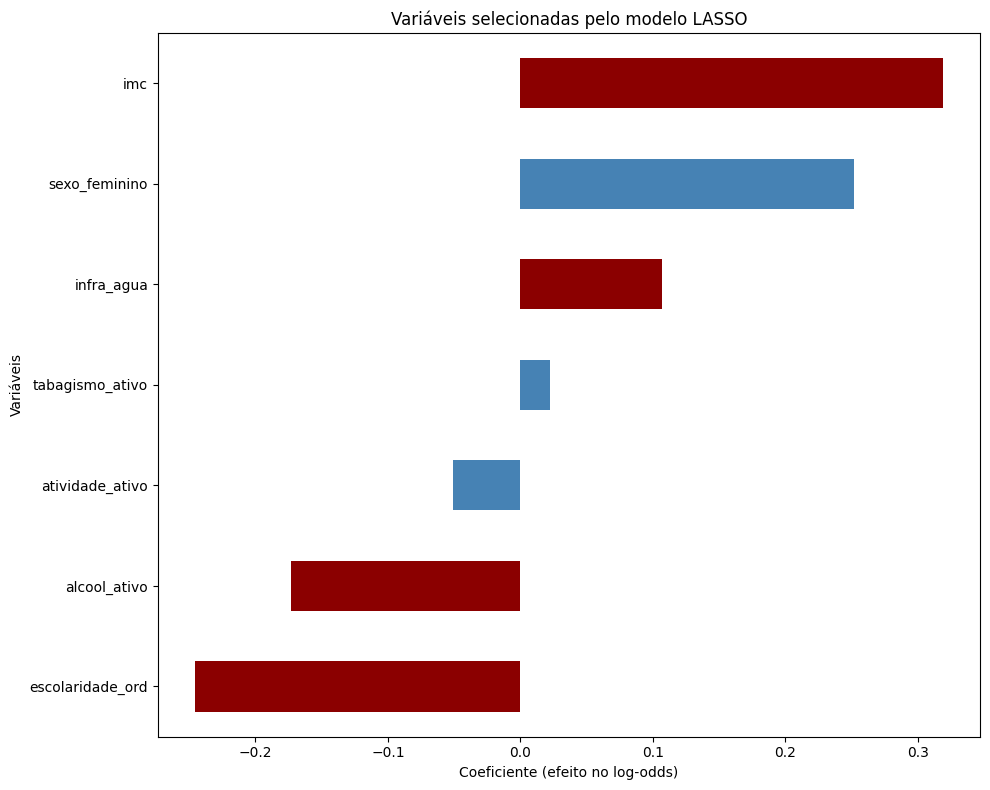

In [78]:

cores = coeficientes_lasso1.apply(lambda x: "darkred" if x > 0 else "steelblue")

plt.figure(figsize=(10,8))

coeficientes_lasso1.sort_values().plot(
    kind="barh",
    color=cores
)

plt.title("Variáveis selecionadas pelo modelo LASSO")
plt.xlabel("Coeficiente (efeito no log-odds)")
plt.ylabel("Variáveis")

plt.tight_layout()
plt.show()

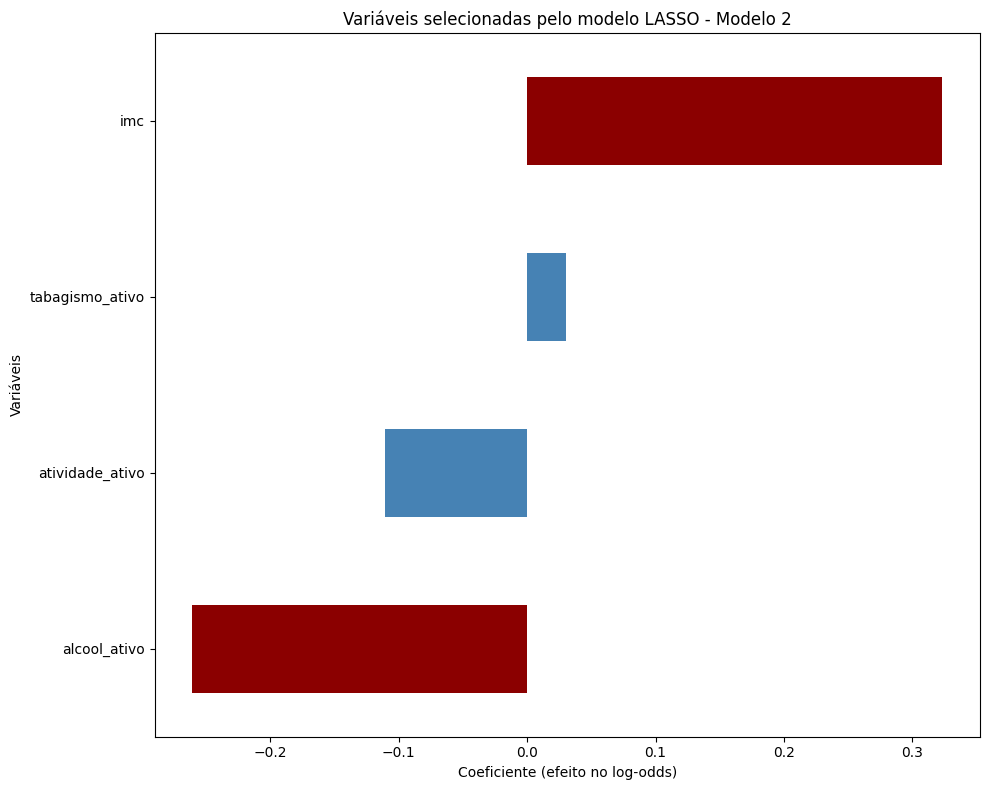

In [79]:
cores = coeficientes_lasso2.apply(lambda x: "darkred" if x > 0 else "steelblue")

plt.figure(figsize=(10,8))

coeficientes_lasso2.sort_values().plot(
    kind="barh",
    color=cores
)

plt.title("Variáveis selecionadas pelo modelo LASSO - Modelo 2")
plt.xlabel("Coeficiente (efeito no log-odds)")
plt.ylabel("Variáveis")

plt.tight_layout()
plt.show()